# Marketplace Dynamics and Behavioral Patterns in Brazilian E-Commerce
*Exploring relationships across pricing, logistics, purchasing patterns, and customer activity.*

## 1. Introduction

This notebook continues directly from *Data Preparation and Merging*, using the cleaned and enriched `order_details` created during that stage.

The original Olist data consisted of nine interconnected relational datasets spanning customers, sellers, products, payments, reviews, geolocation records, order items, order information, and product category translations. These datasets existed across multiple granularities and required careful integration to create a unified analytical view. Preparing the data involved establishing relationships across operational, geographic, and transactional sources while preserving the structure needed for later analysis.

The resulting dataset enters this analysis at the order-item level and contains 113,425 observations. It has been cleaned, validated, and enriched with engineered features related to pricing, logistics, seller characteristics, and marketplace activity.

This exploratory analysis follows questions that emerged throughout preparation and early investigation. Rather than approaching the data with a predefined question, the analysis follows the structure of the marketplace itself. The Olist platform connects pricing, logistics, seller behavior, and customer experience in ways that are difficult to untangle cleanly. Patterns in one area have a way of pointing toward questions in another. The analysis begins broadly and narrows gradually, letting the data surface what matters.

## 2. Environment Setup

This section initializes the notebook environment, including library imports, display settings, and plotting conventions used throughout the analysis.

### 2.1 Libraries

In [1]:
# File handling
import os
import sys

# Data manipulation and utilities
import pandas as pd
import numpy as np
import math
import base64
from IPython.display import display, Markdown, IFrame, HTML

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.graph_objects as go

# Statistical tests
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, gaussian_kde
from statsmodels.stats.multitest import multipletests

# Warnings
import warnings

### 2.2 Environment Configuration

In [2]:
sys.path.append("..")
from config import PROCESSED_DATA

### 2.3 Display Settings

In [3]:
# DataFrame display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Plot theme defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings("ignore")

### 2.4 Color Conventions

In [4]:
# Olist brand colors
NAVY    = "#1A1F5E"
TEAL    = "#2EC4A0"
SKY     = "#4BBFE0"

# Additional colors
MAROON  = "#7F1B21"
CORAL   = "#F4845F"
YELLOW  = "#FFD166"


# Binary palettes
PALETTE_ONTIME = {
    True:  TEAL,
    False: CORAL
    }
PALETTE_SELLER_TYPE = {
    "specialist": SKY,
    "generalist": TEAL
    }

# Review score palette (1–5)
PALETTE_REVIEW = {
    1: CORAL,
    2: YELLOW,
    3: TEAL,
    4: SKY,
    5: NAVY
}

# Heatmap / sequential
CMAP_SEQ = sns.light_palette(TEAL, as_cmap=True)
CMAP_DIV = sns.diverging_palette(357, 170, s=75, l=50, as_cmap=True)

# Categorical palette (up to 10 categories)
CATEGORY_PALETTE = sns.color_palette("muted", 10)

# Single-variable plots
SINGLE_COLOR = SKY

## 3. Unified Marketplace Overview
The analysis begins by loading the cleaned and enriched `order_details` dataset created during the data preparation stage.

In [5]:
df = pd.read_parquet(os.path.join(PROCESSED_DATA, "order_details.parquet"))

In [6]:
# Dataset summary
n_rows = f"{df.shape[0]:,}"
n_features = df.shape[1]

purchase_min = (
    df["order_purchase_timestamp"]
    .min()
    .strftime("%b %Y")
)

purchase_max = (
    df["order_purchase_timestamp"]
    .max()
    .strftime("%b %Y")
)

purchase_window = f"{purchase_min} to {purchase_max}"

In [7]:
display(Markdown(f"""
**Dataset at a Glance**

| | |
|---|---|
| **Rows** | {n_rows} |
| **Features** | {n_features} |
| **Granularity** | Order-item level |
| **Order purchase window** | {purchase_window} |
| **Source** | `order_details.parquet` (output of *Data Preparation and Merging*) |
| **Marketplace entities** | Customers, sellers, products, orders, order items, payments, reviews, geolocation data, and product category translations |
| **Representative engineered features** | Logistics (`delivery_delay_days`, `customer_seller_distance_miles`), pricing (`freight_to_price_ratio`), seller profiling (`seller_type`, category concentration metrics), and product characteristics (`product_volume_cm3`) |
| **Note** | Outliers were retained. Missing delivery timestamps primarily correspond to valid order lifecycle states, including canceled, unavailable, and in-transit orders. |
"""))


**Dataset at a Glance**

| | |
|---|---|
| **Rows** | 113,425 |
| **Features** | 68 |
| **Granularity** | Order-item level |
| **Order purchase window** | Sep 2016 to Oct 2018 |
| **Source** | `order_details.parquet` (output of *Data Preparation and Merging*) |
| **Marketplace entities** | Customers, sellers, products, orders, order items, payments, reviews, geolocation data, and product category translations |
| **Representative engineered features** | Logistics (`delivery_delay_days`, `customer_seller_distance_miles`), pricing (`freight_to_price_ratio`), seller profiling (`seller_type`, category concentration metrics), and product characteristics (`product_volume_cm3`) |
| **Note** | Outliers were retained. Missing delivery timestamps primarily correspond to valid order lifecycle states, including canceled, unavailable, and in-transit orders. |


## 4. Supply Chain and Logistics

E-commerce marketplaces rely on a network of geographic and operational relationships that influence how products move from sellers to customers. This section explores Olist's supply chain structure, examining how distance, product characteristics, and freight costs interact and how those relationships influence delivery outcomes.

### 4.1 Geographic Distribution of Marketplace Activity

Before examining shipping distance directly, it is useful to understand where marketplace activity is concentrated across Brazil. Because the data is structured at the order-item level, areas with higher density reflect greater concentrations of customer and seller activity rather than unique locations alone. These geographic patterns provide important context for later analyses involving distance, freight costs, and delivery behavior.

In [8]:
df_fulfilled = df[df['has_items']]

# Compute customer density
cust_coords = df_fulfilled[['customer_lng', 'customer_lat']].values.T
cust_kde = gaussian_kde(cust_coords)
cust_density = cust_kde(cust_coords)

# Compute seller density
sell_coords = df_fulfilled[['seller_lng', 'seller_lat']].values.T
sell_kde = gaussian_kde(sell_coords)
sell_density = sell_kde(sell_coords)

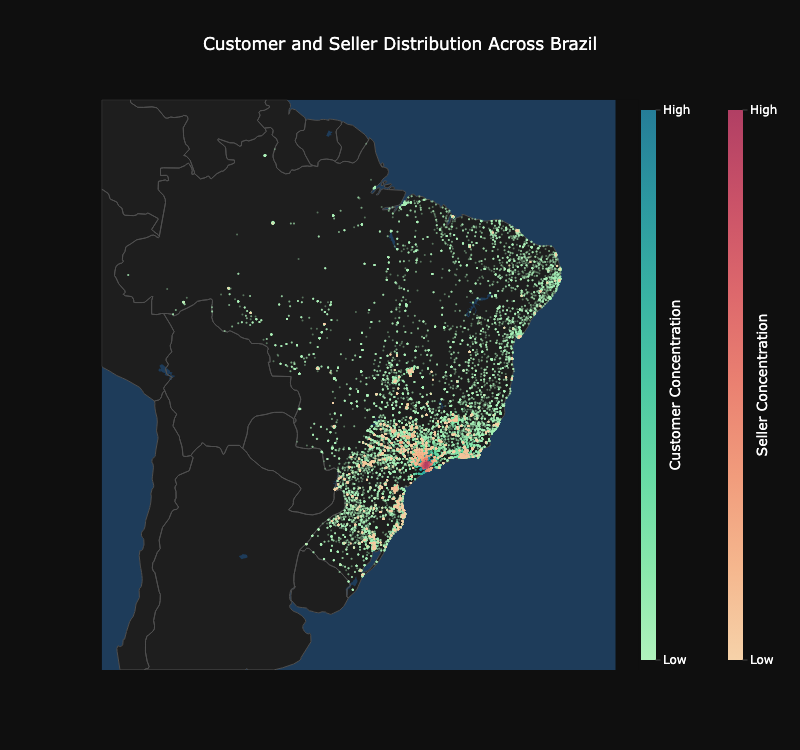

In [9]:
fig = go.Figure()

fig.update_layout(
    # Background
    paper_bgcolor='rgb(15, 15, 15)',   # outer background
    plot_bgcolor='rgb(15, 15, 15)',    # inner background
    font=dict(color='white'),
    title=dict(text='Customer and Seller Distribution Across Brazil', x=0.5),
    width=800,
    height=750,
    geo=dict(
        # map box background
        bgcolor='rgb(15, 15, 15)',
        resolution=50,

        # land configuration
        showland=True,
        landcolor='rgb(30, 30, 30)',
        subunitcolor='rgb(80, 80, 80)',

        # country configuration
        showcountries=True,
        countrycolor='rgb(80, 80, 80)',
        
        # lake configuration
        showlakes=True,
        lakecolor='rgb(30, 60, 90)',

        # ocean configuration      
        showocean=True,
        oceancolor='rgb(30, 60, 90)',

        # Brazil-focused view
        scope='south america',
        lonaxis=dict(range=[-75.0, -28.0]),
        lataxis=dict(range=[-40.0, 6.0])
    )
)

# Customer layer
fig.add_trace(go.Scattergeo(
    lat=df_fulfilled['customer_lat'],
    lon=df_fulfilled['customer_lng'],
    name='Customers',
    marker=dict(
        color=cust_density,
        colorscale='tealgrn',
        reversescale=False,
        opacity=0.4,
        size=2,
        colorbar=dict(
            title=dict(text='Customer Concentration', side='right'),
            x=0.95,
            thickness=15,
            outlinecolor='rgba(68,68,68,0)',
            ticks='outside',
            tickvals=[cust_density.min(), cust_density.max()],
            ticktext=['Low', 'High'],
            bgcolor='rgba(0,0,0,0)',       # transparent colorbar background
        )
    )
))

# Seller layer
fig.add_trace(go.Scattergeo(
    lat=df_fulfilled['seller_lat'],
    lon=df_fulfilled['seller_lng'],
    name='Sellers',
    marker=dict(
        color=sell_density,
        colorscale='Redor',
        reversescale=False,
        opacity=0.4,
        size=2,
        colorbar=dict(
            title=dict(text='Seller Concentration', side='right'),
            x=1.1,
            thickness=15,
            outlinecolor='rgba(68,68,68,0)',
            ticks='outside',
            tickvals=[sell_density.min(), sell_density.max()],
            ticktext=['Low', 'High'],
            bgcolor='rgba(0,0,0,0)',       # transparent colorbar background
        )
    )
))

fig.update_traces(showlegend=False)
fig.show(renderer="png")